In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')

In [3]:
df.shape

(32581, 12)

In [4]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [5]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [6]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

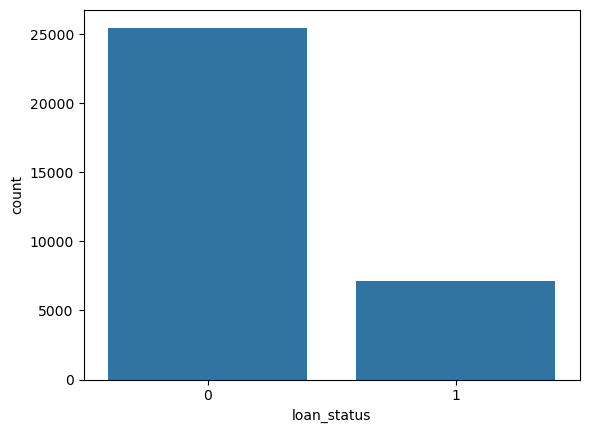

In [7]:
sns.countplot(x='loan_status', data=df)

In [8]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
numeric_only = df.select_dtypes(include=np.number).columns

In [10]:
numeric_only

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

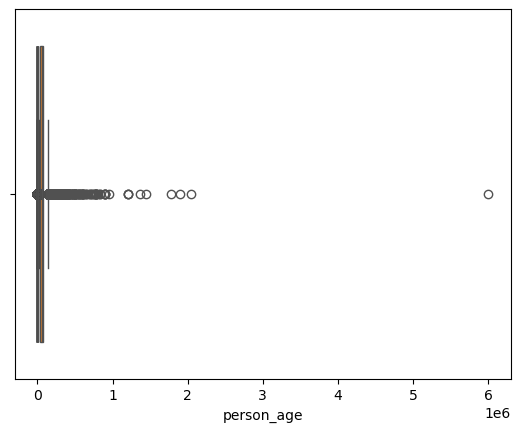

In [11]:
for i in numeric_only:
    sns.boxplot(x=df[i])

In [12]:
(df['person_age']>100).sum()

np.int64(5)

In [13]:
(df['person_emp_length']>60).sum()

np.int64(2)

<Axes: >

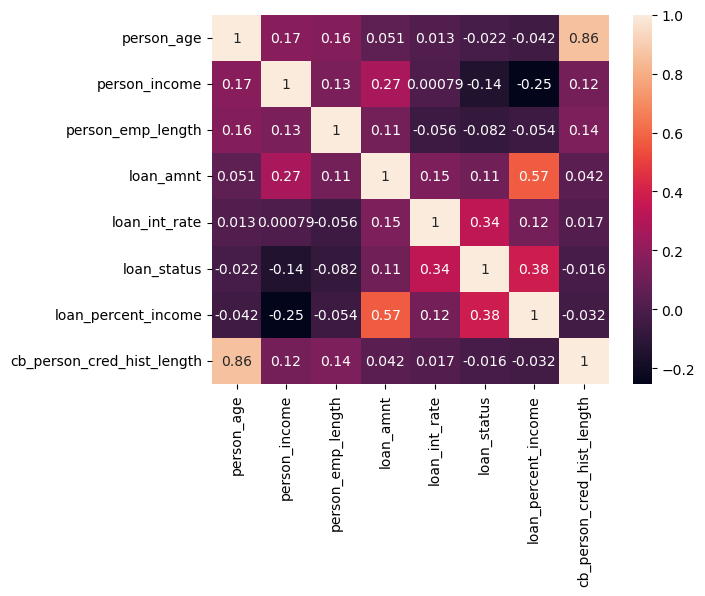

In [14]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [15]:
df_copy = df.copy()

In [16]:
df_copy.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [17]:
df_copy.shape

(32581, 12)

In [18]:
df_copy.drop_duplicates(inplace=True)

In [19]:
df_copy.shape

(32416, 12)

In [20]:
df_copy = df_copy[df_copy['person_age']>=18]

In [21]:
df_copy = df_copy[df_copy['person_age']<100]

In [22]:
df_copy = df_copy[df_copy['person_emp_length']<=df_copy['person_age']]

In [23]:
df_copy = df_copy[df_copy['person_emp_length']<60]

In [24]:
X = df_copy.drop('loan_status',axis = 1)
y = df_copy['loan_status']
from sklearn.model_selection import train_test_split

x_train , x_test, y_train , y_test = train_test_split(X,y,random_state=42,stratify = y,test_size=0.25)


In [25]:
x_train

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
19952,33,37000,MORTGAGE,2.0,PERSONAL,B,13000,10.36,0.35,N,7
9564,21,62500,MORTGAGE,6.0,EDUCATION,A,13200,7.90,0.21,N,3
29386,49,70000,RENT,4.0,EDUCATION,B,17000,11.71,0.24,N,16
14348,23,105000,MORTGAGE,4.0,VENTURE,B,19000,11.99,0.18,N,3
8636,25,59796,MORTGAGE,4.0,HOMEIMPROVEMENT,B,7000,9.63,0.12,N,2
...,...,...,...,...,...,...,...,...,...,...,...
13619,22,95000,MORTGAGE,4.0,EDUCATION,A,6400,7.90,0.07,N,4
17726,24,48000,MORTGAGE,4.0,VENTURE,A,5000,5.99,0.10,N,4
30248,43,50000,MORTGAGE,2.0,DEBTCONSOLIDATION,B,5000,9.63,0.10,N,16
29683,49,23004,RENT,6.0,PERSONAL,D,3250,15.21,0.14,N,12


In [26]:
x_test

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
23139,27,58000,RENT,1.0,VENTURE,B,8000,11.36,0.14,N,7
30619,43,60000,MORTGAGE,2.0,MEDICAL,A,9250,5.79,0.15,N,17
30311,41,50780,MORTGAGE,14.0,PERSONAL,B,6000,10.99,0.12,N,17
27135,30,125000,MORTGAGE,14.0,VENTURE,C,7000,NaN,0.06,N,7
17350,21,25000,MORTGAGE,2.0,PERSONAL,B,3600,9.91,0.14,N,4
...,...,...,...,...,...,...,...,...,...,...,...
17763,22,60000,MORTGAGE,6.0,DEBTCONSOLIDATION,A,10000,8.90,0.17,N,3
29917,37,103000,RENT,1.0,EDUCATION,D,10000,15.62,0.10,Y,12
3566,23,37344,MORTGAGE,0.0,EDUCATION,C,3200,12.68,0.09,Y,2
21036,32,45000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,4000,7.49,0.09,N,7


In [27]:

numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## class weight we use for the imbalance classification target value 
## for eg in our data we have more 0's than 1's so to not make our model bias and behave fair
## for creating or giving weights what we do is divide the more occuring account from the less occuring count

In [28]:
y_train.value_counts()

loan_status
0    18536
1     5105
Name: count, dtype: int64

In [29]:
zero, one  = np.bincount(y_train)

In [30]:
scaled_weights = zero/one

In [31]:
scaled_weights

np.float64(3.6309500489715965)

# pipeline and column tranformer for logistic regression

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer

processor_lr = ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]),numeric_cols),

        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value='Missing')),
             ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ])

## pipeline and column transformer for XG boots 

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

processor_xg = ColumnTransformer(
    transformers = [
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median'))
        ]),numeric_cols),

        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ])

In [34]:
from sklearn.linear_model import LogisticRegression
pipeline_lr = Pipeline([
    ('preprocessor',processor_lr),
    ('model',LogisticRegression(max_iter = 1000,random_state=42,class_weight='balanced'))
])

In [35]:
import pip
!pip install xgboost
from xgboost import XGBClassifier
pipeline_xg = Pipeline([
    ('preprocessor',processor_xg),
    ('model',XGBClassifier(n_estimator = 100,max_depth = 5,learning_rate = 0.1,
                           scale_pos_weight=scaled_weights,random_state = 42))
])

### cross validation

In [36]:
from sklearn.model_selection import StratifiedKFold , cross_validate

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}

In [37]:
for model_name , pipeline in [('logistic regression',pipeline_lr),
                             ('XGboost',pipeline_xg)]:

    cv_results = cross_validate(pipeline,x_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
    print(model_name)
    print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
    print(f"Precision : {cv_results['test_precision'].mean()}")
    print(f"Recall : {cv_results['test_recall'].mean()}")
    print(f"F1 : {cv_results['test_f1'].mean()}")
    print()
    

logistic regression
ROC-AUC : 0.8716979046441807
Accuracy : 0.8119366983214418
Precision : 0.5451798746360135
Recall : 0.7778648383937317
F1 : 0.6410342595180546

XGboost
ROC-AUC : 0.9392341013074155
Accuracy : 0.9084640206466276
Precision : 0.7891530902920534
Recall : 0.7864838393731635
F1 : 0.7877527231344269



### evaluation helper function 

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

def evaluate_model(model_name, model, x_test, y_test, threshold=None):

    y_pred_prob = model.predict_proba(x_test)[:, 1]

    if threshold is not None:
        y_pred = (y_pred_prob > threshold).astype(int)
    else:
        y_pred = model.predict(x_test)

    accuracy_s = accuracy_score(y_test, y_pred)
    precision_s = precision_score(y_test, y_pred)
    recall_s = recall_score(y_test, y_pred)
    f1_s = f1_score(y_test, y_pred)

    conf_matrix = confusion_matrix(y_test, y_pred)
    classif_report = classification_report(y_test, y_pred)

    print(f"{model_name} Metrics:")

    if threshold is not None:
        print(f"Used Threshold : {threshold:.2f}")

    print(f"Accuracy : {accuracy_s:.2f}")
    print(f"Precision : {precision_s:.2f}")
    print(f"Recall : {recall_s:.2f}")
    print(f"F1 : {f1_s:.2f}")

    print()
    print(f"{model_name} Classification Report:")
    print(classif_report)

    sns.heatmap(conf_matrix, annot=True, fmt="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Value")
    plt.ylabel("Actual Value")
    plt.show()

    precisions, recalls, pr_thresholds = precision_recall_curve(
        y_test, y_pred_prob
    )

    plt.plot(recalls, precisions)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.show()
    

### baseline model - logistic regression

In [39]:
baseline_model = Pipeline([
    ('processor',processor_lr),
    ('model',LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(x_train,y_train)

,steps,"[('processor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


baseline logistic regression Metrics:
Accuracy : 0.82
Precision : 0.55
Recall : 0.78
F1 : 0.65

baseline logistic regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88      6179
           1       0.55      0.78      0.65      1702

    accuracy                           0.82      7881
   macro avg       0.74      0.80      0.76      7881
weighted avg       0.85      0.82      0.83      7881



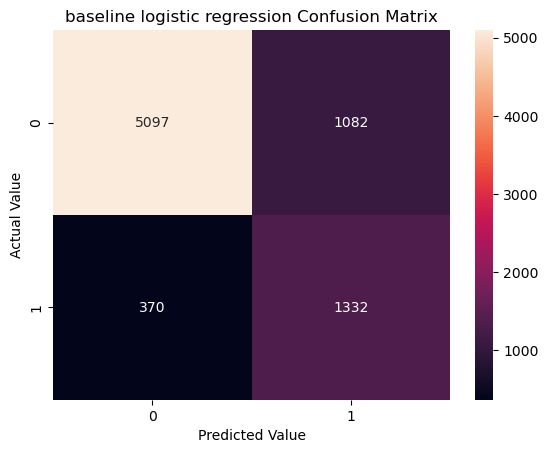

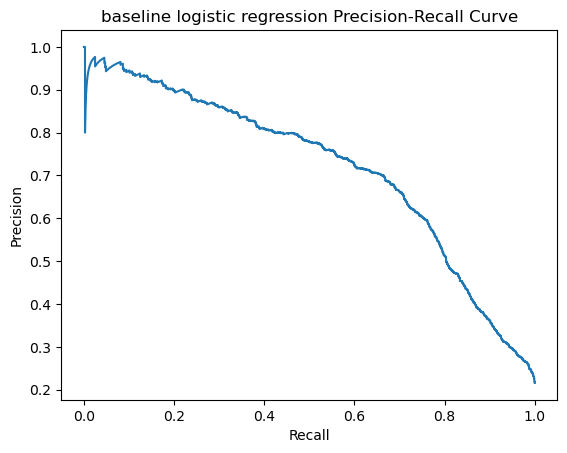

In [40]:
evaluate_model('baseline logistic regression',baseline_model,x_test,y_test)

### hyperparameter tunning of XGboost model

In [41]:
xg_model = Pipeline([
    ('processor',processor_xg),
    ('model',XGBClassifier(learning_rate = 0.1,scale_pos_weight = scaled_weights,
                          random_state = 42))
])
xg_model.fit(x_train,y_train)

,steps,"[('processor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "model__n_estimators": randint(150, 600),
    "model__max_depth" : randint(3,9),
    "model__learning_rate" : uniform(0.01, 0.5),
    "model__subsample": uniform(0.6,0.4),
    "model__colsample_bytree" :uniform(0.6,0.4),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0 , 5)
}

In [ ]:
random_search = RandomizedSearchCV(xg_model,param_grid,n_iter=150,cv = cv ,
                                   scoring = "average_precision",n_jobs=-1,verbose = 1)
random_search.fit(x_train,y_train)

In [ ]:
random_search.best_params_

In [ ]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

### comparing both models

In [ ]:
evaluate_model("logistice regression",baseline_model,x_test,y_test)

In [ ]:
evaluate_model('XGBoost',random_search,x_test,y_test)

### optimizing the classification threshold

In [50]:
prob = xg_model.predict_proba(x_test)[:,1]

In [51]:
prob

array([0.02049766, 0.03022199, 0.20462878, ..., 0.24659853, 0.15339847,
       0.54603416], shape=(7881,), dtype=float32)

In [52]:
precisions , recalls , thresholds = precision_recall_curve(y_test,prob)

In [54]:
f1 = 2 * (precisions - recalls)/(precisions + recalls + 1e-9)

In [55]:
f1

array([-1.28957529, -1.28950115, -1.28935282, ...,  1.99530516,
        1.9976512 ,  2.        ], shape=(7844,))

In [59]:
import numpy as np
best = np.argmax(f1[:-1])

In [60]:
best_threshold = thresholds[best]

XGMOdel Metrics:
Accuracy : 0.92
Precision : 0.82
Recall : 0.78
F1 : 0.80

XGMOdel Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      6179
           1       0.82      0.78      0.80      1702

    accuracy                           0.92      7881
   macro avg       0.88      0.87      0.87      7881
weighted avg       0.92      0.92      0.92      7881



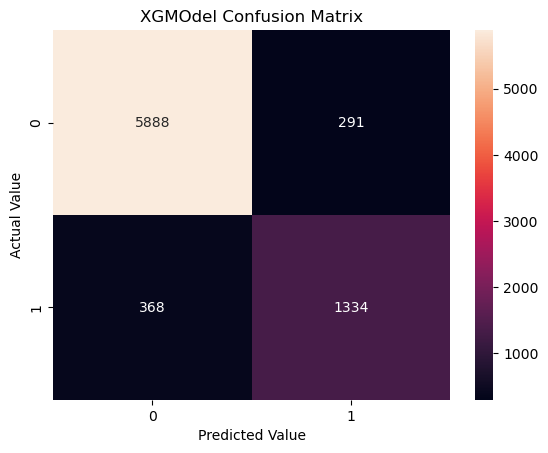

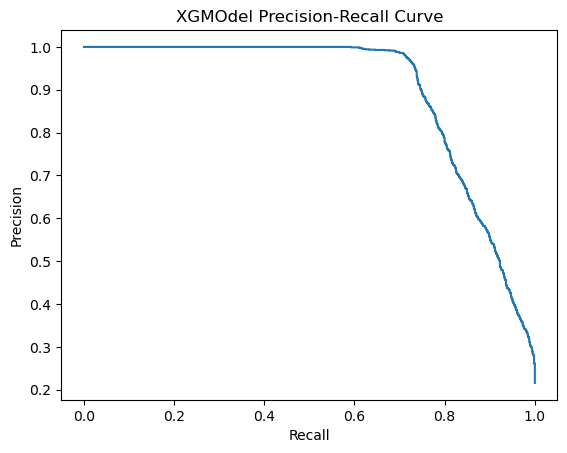

In [63]:
evaluate_model('XGMOdel',xg_model,x_test,y_test)

C:\Users\vyass\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vyass\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vyass\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vyass\anaconda3\Lib\site-pa

XGModel Metrics:
Used Threshold : 1.00
Accuracy : 0.78
Precision : 0.00
Recall : 0.00
F1 : 0.00

XGModel Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      6179
           1       0.00      0.00      0.00      1702

    accuracy                           0.78      7881
   macro avg       0.39      0.50      0.44      7881
weighted avg       0.61      0.78      0.69      7881



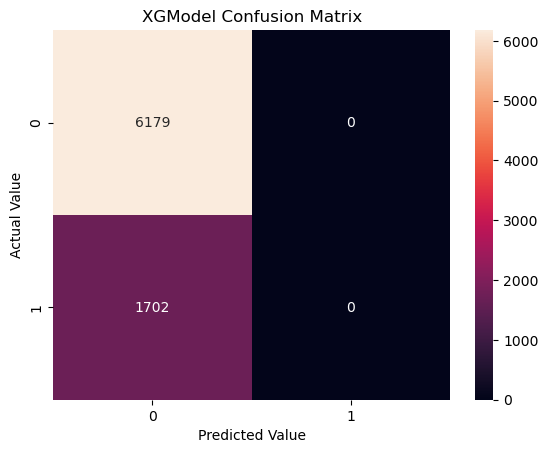

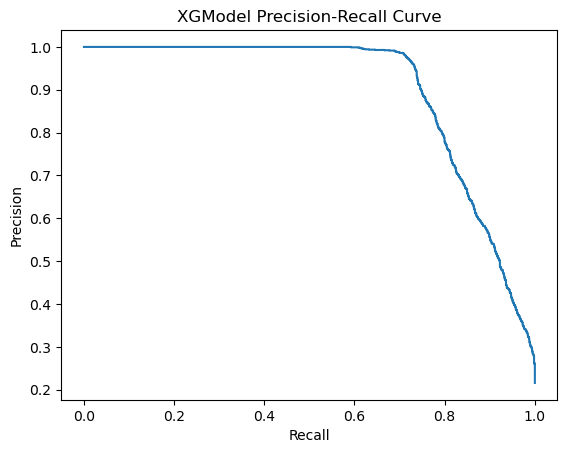

In [62]:
evaluate_model('XGModel',xg_model,x_test,y_test,best_threshold)

### probability calibration

In [68]:
from sklearn.calibration import CalibratedClassifierCV , calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method = 'sigmoid',
    cv = 5
)

In [69]:
calibrated_model.fit(x_train ,y_train)

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [70]:
uncalibrated = xg_model.predict_proba(x_test)[:,1]
calibrated = calibrated_model.predict_proba(x_test)[:,1]

In [71]:
actual_uncal , pred_uncal = calibration_curve(y_test,uncalibrated,n_bins = 10)
actual_cal , pred_cal = calibration_curve(y_test,calibrated,n_bins = 10)

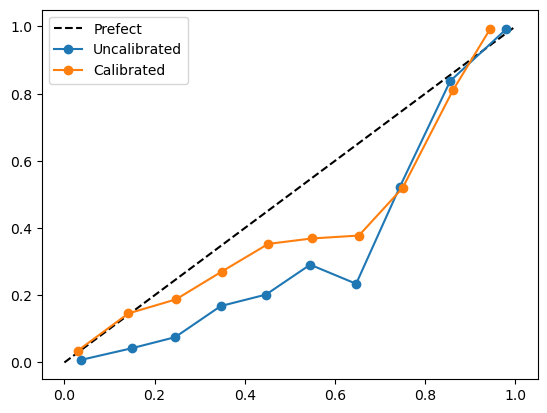

In [73]:
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    pred_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    pred_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

### SHAP interpretation global - local 

In [74]:
!pip install shap
import shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [81]:
xgb_classifier = xg_model.named_steps['model']
     
X_test_transformed = xg_model.named_steps['processor'].transform(x_test)
     
feature_names = xg_model.named_steps['processor'].get_feature_names_out()
     
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-0.01946654, -0.24156915,  0.07434151, ..., -0.01240527,
        -0.0097881 ,  0.        ],
       [-0.15079583, -0.63982755,  0.03492374, ..., -0.00752026,
        -0.03433074,  0.        ],
       [-0.08317511, -0.11429007,  0.0418504 , ..., -0.00970144,
        -0.02183276,  0.        ],
       ...,
       [-0.01079587,  0.19858365,  0.01662364, ..., -0.00955328,
         0.02623709,  0.        ],
       [-0.11428513, -0.08610731,  0.10191659, ..., -0.008498  ,
        -0.00973111,  0.        ],
       [ 0.10301983, -0.15600389, -0.50199777, ..., -0.00921161,
        -0.00239087,  0.        ]], shape=(7881, 26), dtype=float32)

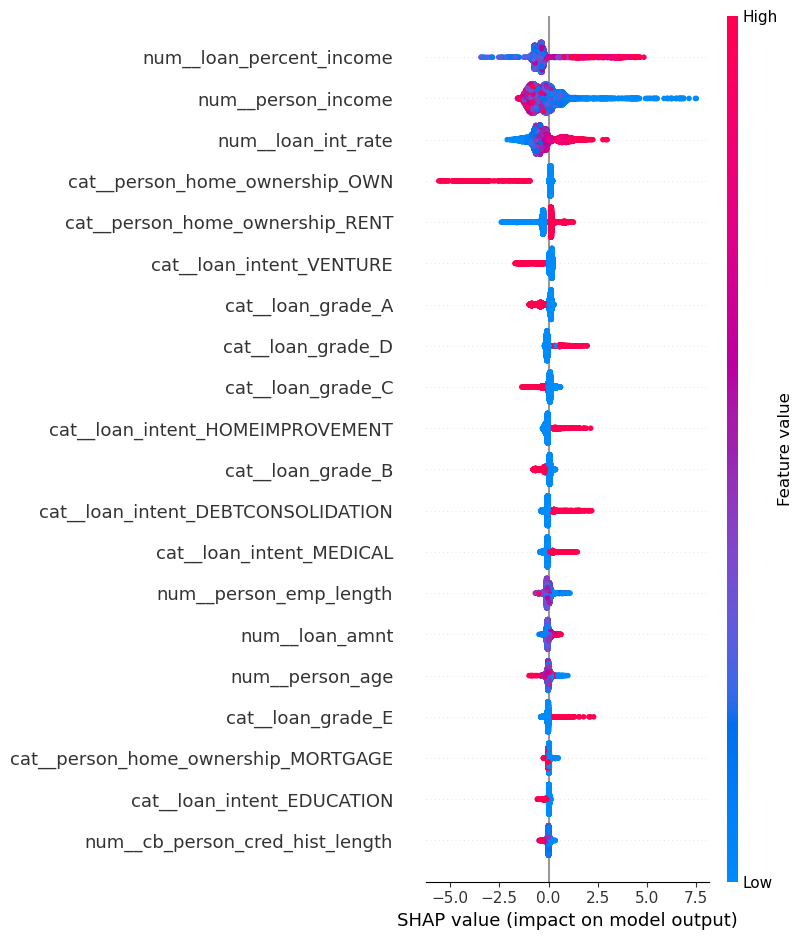

In [82]:
shap.summary_plot(shap_values, X_test_df)

### local explanation

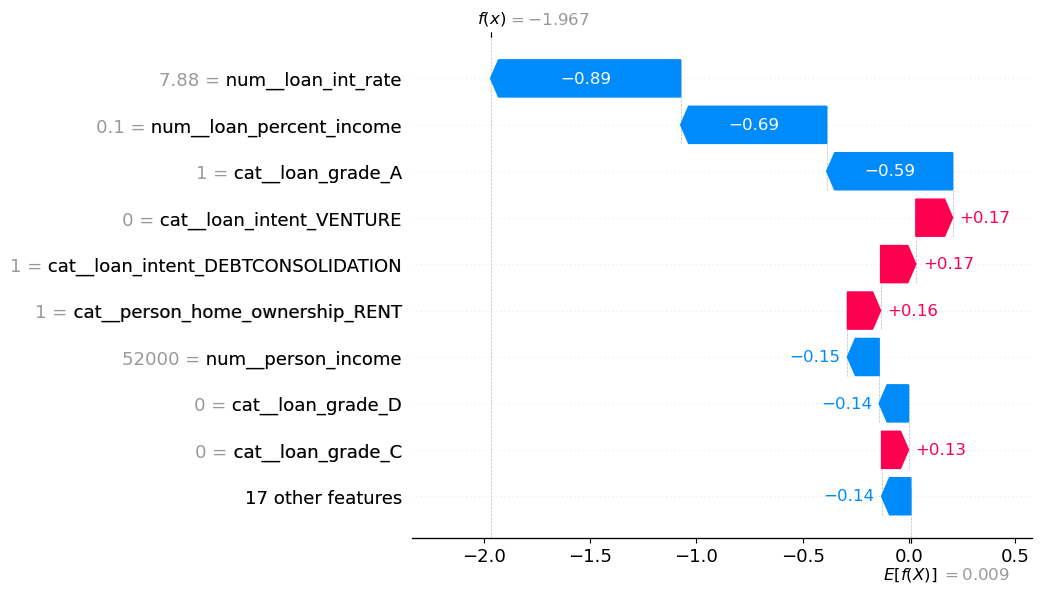

In [83]:
row_index = 5
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

### false positive and false negative

In [86]:

y_pred = random_search.predict(x_test)

result_df = x_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred
     

false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]
     
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 297
False Negative : 333


### saving the final model

In [88]:
import joblib
joblib.dump(calibrated_model,'credit_risk_model.pkl')

['credit_risk_model.pkl']

In [89]:
joblib.dump(best_threshold,'best_threshold.pkl')

['best_threshold.pkl']